# 02 Modeling: Volatility Forecasting

This notebook trains and evaluates several volatility forecasting models. The notebook uses reusable helper functions from `src/` when available, while keeping the modeling workflow readable and reproducible.

Main workflow:

1. Load the processed modeling dataset from `data/model_data.csv`
2. Split the data using a time-ordered train/test split
3. Train baseline, tree-based, boosting, stacking, and GARCH models
4. Compare models using RMSE and MAE

## 1. Import packages and project utilities

The `src/` folder stores reusable functions for models and evaluation. If the helper files are not available or not fully updated, the notebook falls back to local definitions so the workflow still runs.

In [4]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

from xgboost import XGBRegressor
from arch import arch_model

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [5]:
from src.models import get_ridge, get_rf, get_extra, get_xgb
from src.evaluation import evaluate
print("Using helper functions from src/.")

Using helper functions from src/.


## 2. Load processed modeling data

The dataset was created in `01_data_setup.ipynb`. The target variable is next-day realized volatility, and the features are lagged volatility values.

In [6]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

model_data_path = DATA_DIR / "model_data.csv"
returns_path = DATA_DIR / "returns.csv"

df = pd.read_csv(model_data_path, index_col=0, parse_dates=True)
returns = pd.read_csv(returns_path, index_col=0, parse_dates=True)

df.head()

,vol,vol_lag1,vol_lag5,vol_lag10,vol_lag21,target
Date,,,,,,
2015-03-05,0.076596,0.088955,0.117697,0.138446,0.178844,0.092105
2015-03-06,0.092105,0.076596,0.106632,0.138761,0.167060,0.086748
2015-03-09,0.086748,0.092105,0.104769,0.130694,0.165992,0.104232
2015-03-10,0.104232,0.086748,0.092912,0.128510,0.161692,0.103366
2015-03-11,0.103366,0.104232,0.088955,0.128742,0.150426,0.106207


In [7]:
feature_cols = ["vol_lag1", "vol_lag5", "vol_lag10", "vol_lag21"]

X = df[feature_cols]
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (2473, 4)
Target shape: (2473,)


## 3. Time-ordered train/test split

Because this is a time-series forecasting problem, we do not randomly shuffle the data. The first 80% of observations are used for training, and the remaining 20% are held out for testing.

In [8]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training period:", X_train.index.min(), "to", X_train.index.max())
print("Testing period:", X_test.index.min(), "to", X_test.index.max())

Training period: 2015-03-05 00:00:00 to 2023-01-10 00:00:00
Testing period: 2023-01-11 00:00:00 to 2024-12-30 00:00:00


## 4. Baseline model

The baseline predicts tomorrow's volatility using today's volatility. This is a strong benchmark because volatility is highly persistent.

In [9]:
y_pred_baseline = X_test["vol_lag1"]

baseline_rmse, baseline_mae = evaluate(y_test, y_pred_baseline)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 0.010238094043254502
Baseline MAE: 0.0069230401538838944


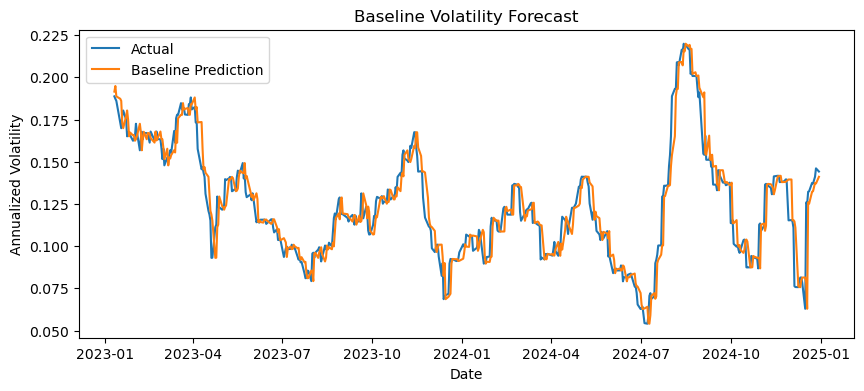

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_baseline, label="Baseline Prediction")
plt.title("Baseline Volatility Forecast")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()

## 5. Machine learning models

This section trains Ridge, Random Forest, Extra Trees, XGBoost, and Stacking models. Model constructors are imported from `src.models` when available.

In [11]:
models = {
    "Ridge": get_ridge(),
    "Random Forest": get_rf(),
    "Extra Trees": get_extra(),
    "XGBoost": get_xgb()
}

predictions = {}
metrics = {
    "Baseline": {
        "RMSE": baseline_rmse,
        "MAE": baseline_mae
    }
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse, mae = evaluate(y_test, y_pred)

    predictions[name] = pd.Series(y_pred, index=y_test.index)
    metrics[name] = {"RMSE": rmse, "MAE": mae}

    print(f"{name} RMSE: {rmse:.6f}")
    print(f"{name} MAE:  {mae:.6f}")
    print()

Ridge RMSE: 0.010577
Ridge MAE:  0.007483

Random Forest RMSE: 0.010234
Random Forest MAE:  0.007193

Extra Trees RMSE: 0.010538
Extra Trees MAE:  0.007469

XGBoost RMSE: 0.009899
XGBoost MAE:  0.007076



## 6. Stacking model

The stacking model combines several base models and uses Ridge regression as the final estimator. This allows the final model to combine linear, bagging, and boosting-based predictions.

In [12]:
base_models = [
    ("ridge", get_ridge()),
    ("rf", get_rf()),
    ("extra", get_extra()),
    ("xgb", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
]

stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=1.0),
    passthrough=True,
    cv=5
)

stacking.fit(X_train, y_train)

y_pred_stack = stacking.predict(X_test)
stack_rmse, stack_mae = evaluate(y_test, y_pred_stack)

predictions["Stacking"] = pd.Series(y_pred_stack, index=y_test.index)
metrics["Stacking"] = {"RMSE": stack_rmse, "MAE": stack_mae}

print("Stacking RMSE:", stack_rmse)
print("Stacking MAE:", stack_mae)

Stacking RMSE: 0.010465646783777543
Stacking MAE: 0.007258058300518828


## 7. Optional tuned XGBoost with time-series cross-validation

This step is optional but useful for a more professional workflow. The tuning uses `TimeSeriesSplit` to avoid look-ahead bias.

In [13]:
ts_cv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=15,
    cv=ts_cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

xgb_tuned_rmse, xgb_tuned_mae = evaluate(y_test, y_pred_xgb_tuned)

predictions["Tuned XGBoost"] = pd.Series(y_pred_xgb_tuned, index=y_test.index)
metrics["Tuned XGBoost"] = {"RMSE": xgb_tuned_rmse, "MAE": xgb_tuned_mae}

print("Best XGBoost parameters:")
print(search.best_params_)
print("Tuned XGBoost RMSE:", xgb_tuned_rmse)
print("Tuned XGBoost MAE:", xgb_tuned_mae)

Best XGBoost parameters:
{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Tuned XGBoost RMSE: 0.010123702792743262
Tuned XGBoost MAE: 0.007107234486455669


## 8. GARCH(1,1) benchmark

GARCH is included as a finance-standard volatility model. Returns are multiplied by 100 before fitting for numerical stability, and the forecasted volatility is converted back to annualized decimal units for comparison with the machine learning models.

In [14]:
spy_returns = returns["SPY"] * 100

spy_train = spy_returns.loc[X_train.index]
spy_test = spy_returns.loc[X_test.index]

garch = arch_model(
    spy_train,
    vol="Garch",
    p=1,
    q=1,
    mean="Constant",
    dist="normal"
)

garch_result = garch.fit(disp="off")
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2573.46
Distribution:                  Normal   AIC:                           5154.92
Method:            Maximum Likelihood   BIC:                           5177.28
                                        No. Observations:                 1978
Date:                Tue, May 05 2026   Df Residuals:                     1977
Time:                        02:26:00   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0860  1.660e-02      5.182  2.198e-07 [5.349e-0

In [15]:
forecast = garch_result.forecast(horizon=len(spy_test), reindex=False)

garch_var = forecast.variance.values[-1, :]
garch_vol = np.sqrt(garch_var) * np.sqrt(252) / 100

garch_pred = pd.Series(garch_vol, index=y_test.index)

garch_rmse, garch_mae = evaluate(y_test, garch_pred)

predictions["GARCH(1,1)"] = garch_pred
metrics["GARCH(1,1)"] = {"RMSE": garch_rmse, "MAE": garch_mae}

print("GARCH RMSE:", garch_rmse)
print("GARCH MAE:", garch_mae)

GARCH RMSE: 0.10777922573668722
GARCH MAE: 0.10082965520181378


## 9. Model comparison

RMSE and MAE are used to compare forecast accuracy. Lower values indicate better predictive performance.

In [16]:
results = (
    pd.DataFrame(metrics)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
    .sort_values("RMSE")
)

results

,Model,RMSE,MAE
4,XGBoost,0.009899,0.007076
6,Tuned XGBoost,0.010124,0.007107
2,Random Forest,0.010234,0.007193
0,Baseline,0.010238,0.006923
5,Stacking,0.010466,0.007258
3,Extra Trees,0.010538,0.007469
1,Ridge,0.010577,0.007483
7,"GARCH(1,1)",0.107779,0.100830


In [17]:
results.to_csv(DATA_DIR / "model_comparison.csv", index=False)
print("Saved model comparison to:", DATA_DIR / "model_comparison.csv")

Saved model comparison to: /Users/vinsber/Desktop/volatility-prediction/data/model_comparison.csv


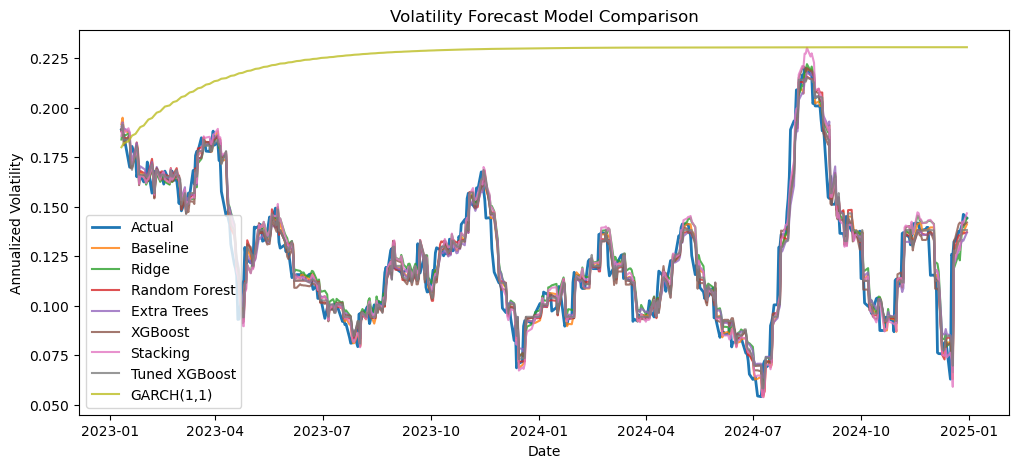

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, y_pred_baseline, label="Baseline", alpha=0.8)

for name in ["Ridge", "Random Forest", "Extra Trees", "XGBoost", "Stacking", "Tuned XGBoost", "GARCH(1,1)"]:
    if name in predictions:
        plt.plot(predictions[name].index, predictions[name], label=name, alpha=0.8)

plt.title("Volatility Forecast Model Comparison")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.show()

## 10. Save predictions for VaR application

The next notebook, `03_application_var.ipynb`, can use these saved predictions to construct dynamic VaR estimates.

In [19]:
prediction_df = pd.DataFrame(index=y_test.index)
prediction_df["actual_vol"] = y_test
prediction_df["baseline"] = y_pred_baseline

for name, pred in predictions.items():
    clean_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
    prediction_df[clean_name] = pred

prediction_df.to_csv(DATA_DIR / "model_predictions.csv")
prediction_df.head()

,actual_vol,baseline,ridge,random_forest,extra_trees,xgboost,stacking,tuned_xgboost,garch11
Date,,,,,,,,,
2023-01-11,0.188726,0.191554,0.183848,0.187940,0.190330,0.189243,0.185704,0.188642,0.179951
2023-01-12,0.187296,0.194858,0.188454,0.191157,0.192541,0.189748,0.191815,0.191547,0.180987
2023-01-13,0.186048,0.188726,0.185616,0.184646,0.189492,0.180931,0.187011,0.183771,0.181998
2023-01-17,0.173275,0.187296,0.186812,0.184498,0.188184,0.185585,0.189535,0.183823,0.182986
2023-01-18,0.169871,0.186048,0.185002,0.184436,0.187369,0.185345,0.187478,0.183823,0.183951


## 11. Interpretation

The baseline model is difficult to beat because volatility is highly persistent: recent volatility is often a strong predictor of near-future volatility. Machine learning models such as Random Forest, Extra Trees, XGBoost, and Stacking may improve performance when they capture nonlinear relationships among lagged volatility features, but their improvement must be judged against the simple baseline.

GARCH(1,1) provides a finance-standard benchmark based on conditional variance dynamics. Comparing GARCH with machine learning models helps distinguish between traditional econometric volatility modeling and data-driven forecasting approaches.

Overall, the best model is the one with the lowest out-of-sample RMSE and MAE on the time-ordered test set. These forecasts can then be used in the next stage of the project to construct dynamic Value-at-Risk estimates.